# B. 공식 validation 기준선·평가

C1/C2와 같은 공식 train/validation 분할과 26차원 전처리를 사용한다. 기본 실행에서는 `test_final.csv`를 읽지 않는다.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

def find_project_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'data' / 'final' / 'train_clean.csv').exists():
            return candidate
    raise FileNotFoundError('data/final/train_clean.csv이 있는 프로젝트 루트를 찾을 수 없습니다.')

ROOT = find_project_root()
FINAL_DIR = ROOT / 'data' / 'final'
RESULT_ROOT = ROOT / 'outputs' if (ROOT / 'outputs').exists() else ROOT / 'results' / 'B'
SCRIPT_DIR = ROOT / 'scripts' if (ROOT / 'scripts').exists() else ROOT / 'members' / 'B'
TRAIN_PATH = FINAL_DIR / 'train_clean.csv'
VALIDATION_PATH = FINAL_DIR / 'validation_final.csv'
print('Project root:', ROOT)

Project root: /Users/feel1p/Desktop/인공지능 공학/AI-Engineering-main 2


## 1. 공식 개발 데이터 확인

In [2]:
train = pd.read_csv(TRAIN_PATH)
validation = pd.read_csv(VALIDATION_PATH)
summary = pd.DataFrame({
    'rows': [len(train), len(validation)],
    'features': [train.shape[1] - 1, validation.shape[1] - 1],
    'duplicates': [train.duplicated().sum(), validation.duplicated().sum()],
    'missing': [train.isna().sum().sum(), validation.isna().sum().sum()],
    'purchase_count': [train['Revenue'].astype(int).sum(), validation['Revenue'].astype(int).sum()],
    'purchase_rate': [train['Revenue'].astype(int).mean(), validation['Revenue'].astype(int).mean()],
}, index=['train', 'validation'])
display(summary.style.format({'purchase_rate': '{:.2%}'}))

,rows,features,duplicates,missing,purchase_count,purchase_rate
train,8543,17,0,0,1335,15.63%
validation,1221,17,0,0,191,15.64%


## 2. 공식 validation 기준선 실행

로지스틱 회귀와 랜덤포레스트를 공식 train에서 학습하고 공식 validation에서 평가한다.

In [3]:
import sys
scripts_directory = str(SCRIPT_DIR)
if scripts_directory not in sys.path:
    sys.path.insert(0, scripts_directory)
from run_baseline import main
main(evaluate_test=False)

Official train: 8,543 rows, 26 features
Official validation: 1,221 rows

Official validation metrics at threshold 0.50
              model          evaluation  threshold  accuracy  precision  recall     f1  roc_auc  average_precision
      Random Forest official validation        0.5    0.8886     0.6471  0.6335 0.6402   0.9213             0.7276
Logistic Regression official validation        0.5    0.8452     0.5036  0.7225 0.5935   0.8796             0.6008

Top validation threshold candidates by F1 (candidates only)
              model  threshold  accuracy  precision  recall     f1  roc_auc  average_precision
Logistic Regression       0.65    0.8804     0.6178  0.6178 0.6178   0.8796             0.6008
Logistic Regression       0.60    0.8706     0.5760  0.6545 0.6127   0.8796             0.6008
Logistic Regression       0.55    0.8640     0.5532  0.6806 0.6103   0.8796             0.6008
      Random Forest       0.45    0.8870     0.6305  0.6702 0.6497   0.9213             0.7276


## 3. 기준 성능과 임계값 후보

In [4]:
metrics = pd.read_csv(RESULT_ROOT / 'metrics' / 'validation_baseline_metrics.csv')
threshold_candidates = pd.read_csv(RESULT_ROOT / 'metrics' / 'validation_threshold_candidates.csv')
formatters = {
    'threshold': '{:.2f}', 'accuracy': '{:.3f}', 'precision': '{:.3f}',
    'recall': '{:.3f}', 'f1': '{:.3f}', 'roc_auc': '{:.3f}',
    'average_precision': '{:.3f}'
}
display(metrics.style.format(formatters))
display(threshold_candidates.style.format(formatters))

,model,evaluation,threshold,accuracy,precision,recall,f1,roc_auc,average_precision
0,Random Forest,official validation,0.50,0.889,0.647,0.634,0.640,0.921,0.728
1,Logistic Regression,official validation,0.50,0.845,0.504,0.723,0.594,0.880,0.601


,model,threshold,accuracy,precision,recall,f1,roc_auc,average_precision
0,Logistic Regression,0.65,0.880,0.618,0.618,0.618,0.880,0.601
1,Logistic Regression,0.60,0.871,0.576,0.654,0.613,0.880,0.601
2,Logistic Regression,0.55,0.864,0.553,0.681,0.610,0.880,0.601
3,Random Forest,0.45,0.887,0.631,0.670,0.650,0.921,0.728
4,Random Forest,0.60,0.901,0.727,0.586,0.649,0.921,0.728
5,Random Forest,0.55,0.895,0.682,0.618,0.648,0.921,0.728


## 4. 발표용 그래프

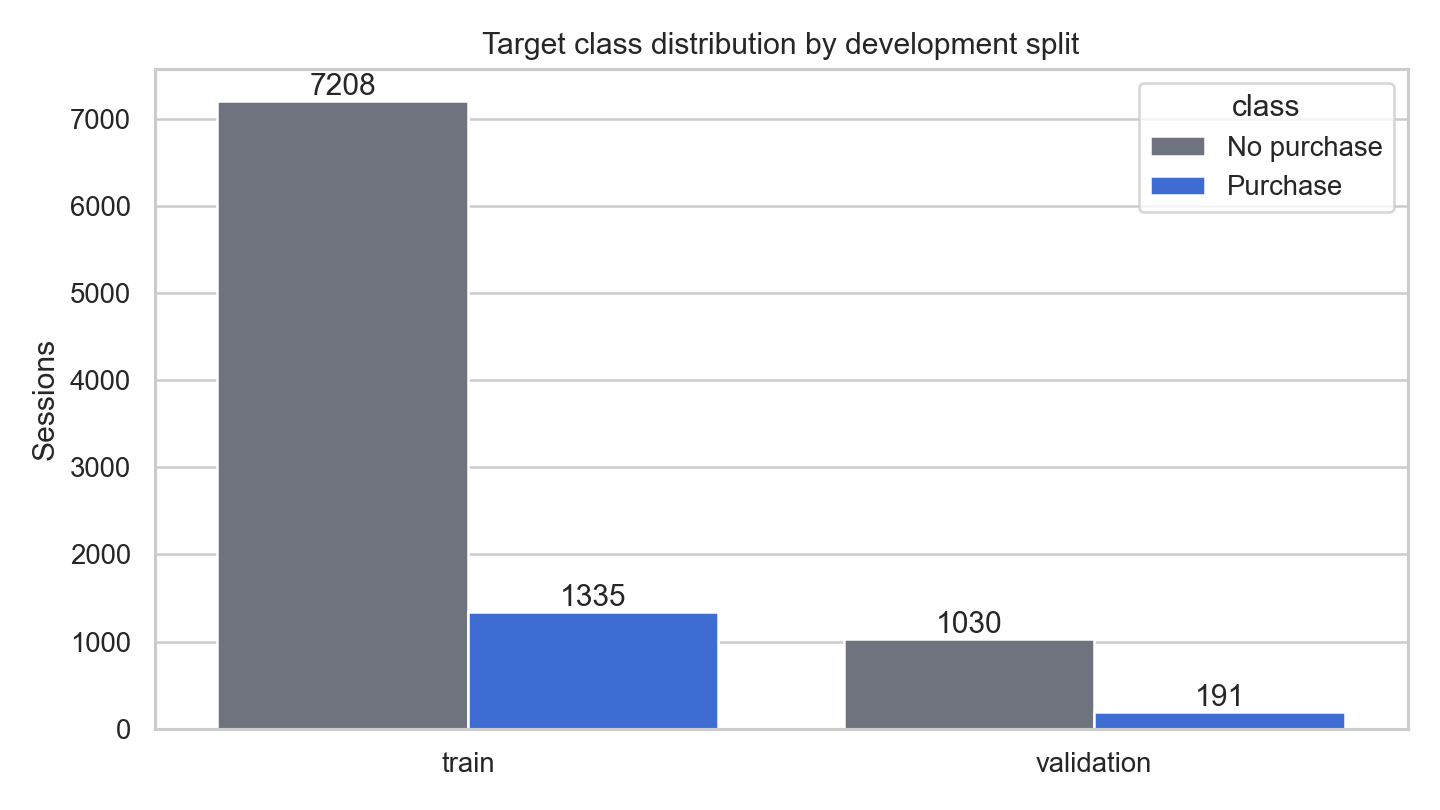

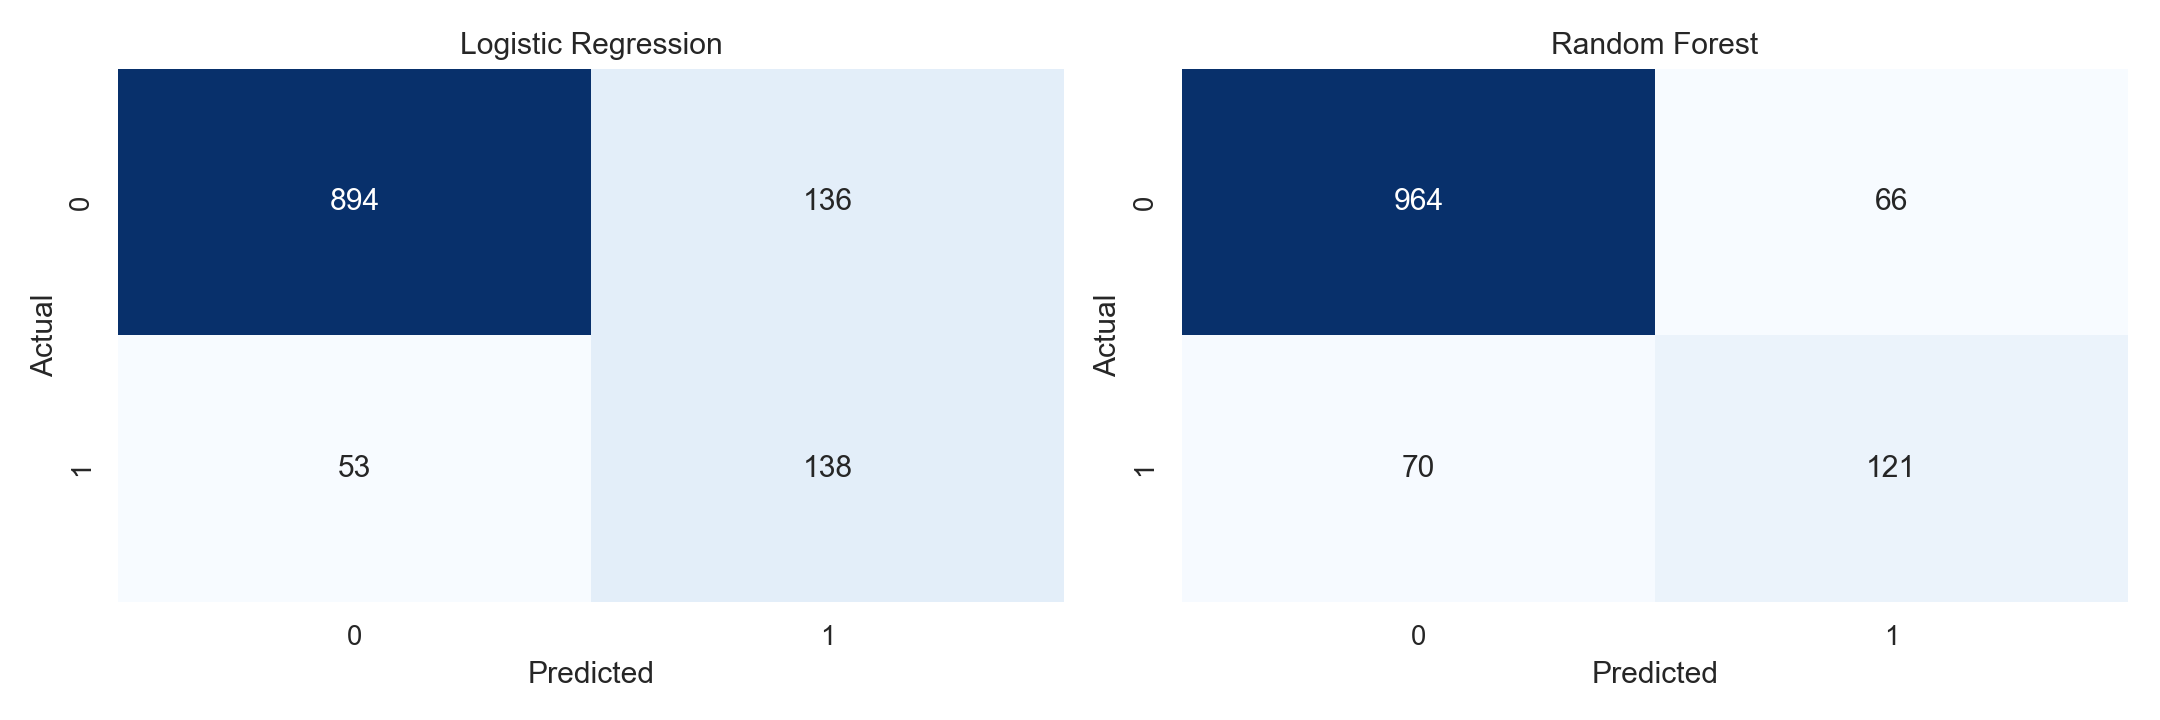

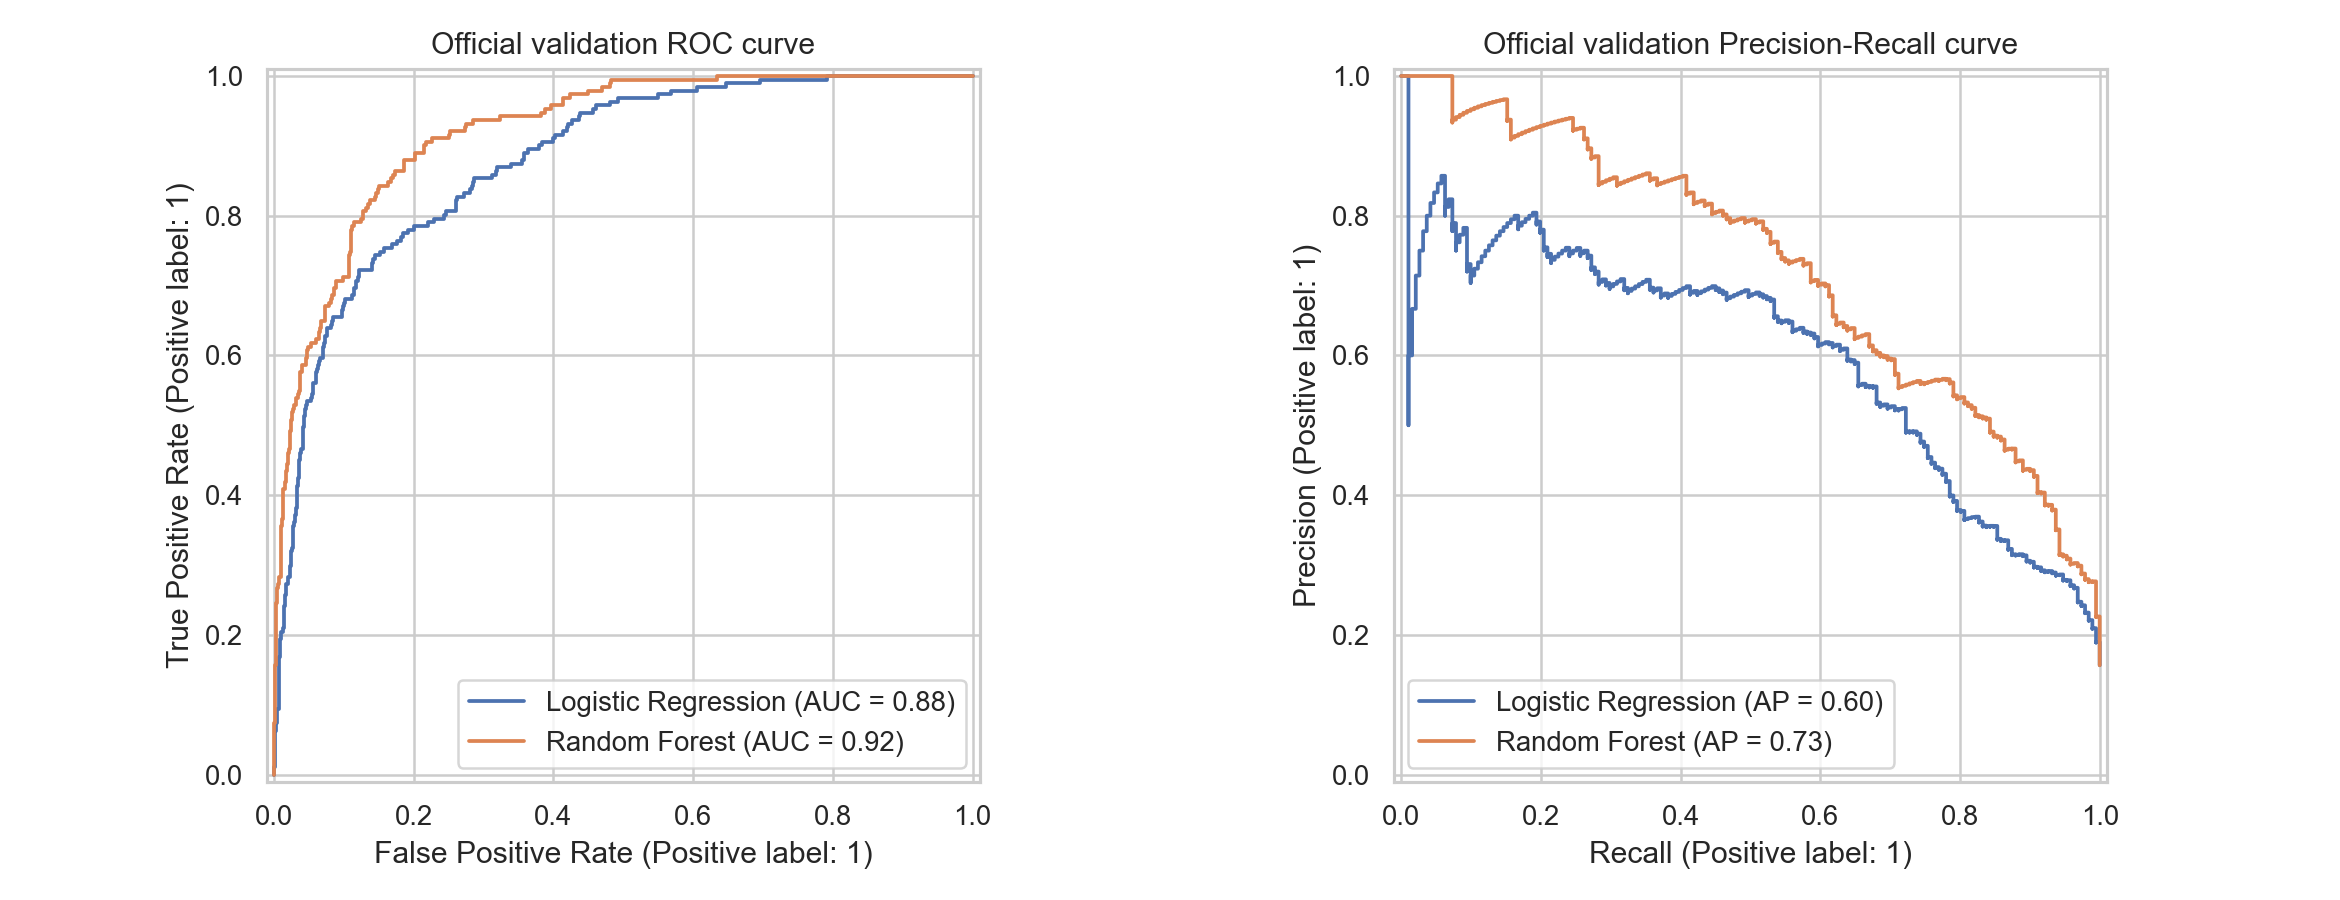

In [5]:
for filename in [
    'development_class_distribution.png',
    'validation_confusion_matrices.png',
    'validation_roc_pr_curves.png',
]:
    display(Image(filename=str(RESULT_ROOT / 'figures' / filename)))

## 5. 클래스 가중치와 PageValues 실험

같은 공식 validation에서 클래스 가중치와 `PageValues` 특징의 영향을 비교한다.

              model    class_weight        feature_set  threshold  accuracy  precision  recall     f1  roc_auc  average_precision
Logistic Regression No class weight       All features        0.5    0.8780     0.7019  0.3822 0.4949   0.8669             0.5984
Logistic Regression        Balanced       All features        0.5    0.8452     0.5036  0.7225 0.5935   0.8796             0.6008
Logistic Regression        Balanced Without PageValues        0.5    0.6290     0.2583  0.7330 0.3820   0.7399             0.3166
      Random Forest No class weight       All features        0.5    0.8952     0.6933  0.5916 0.6384   0.9232             0.7251
      Random Forest        Balanced       All features        0.5    0.8886     0.6471  0.6335 0.6402   0.9213             0.7276
      Random Forest        Balanced Without PageValues        0.5    0.8346     0.4225  0.1571 0.2290   0.7789             0.3663


,model,class_weight,feature_set,threshold,accuracy,precision,recall,f1,roc_auc,average_precision
0,Logistic Regression,No class weight,All features,0.50,0.878,0.702,0.382,0.495,0.867,0.598
1,Logistic Regression,Balanced,All features,0.50,0.845,0.504,0.723,0.594,0.880,0.601
2,Logistic Regression,Balanced,Without PageValues,0.50,0.629,0.258,0.733,0.382,0.740,0.317
3,Random Forest,No class weight,All features,0.50,0.895,0.693,0.592,0.638,0.923,0.725
4,Random Forest,Balanced,All features,0.50,0.889,0.647,0.634,0.640,0.921,0.728
5,Random Forest,Balanced,Without PageValues,0.50,0.835,0.423,0.157,0.229,0.779,0.366


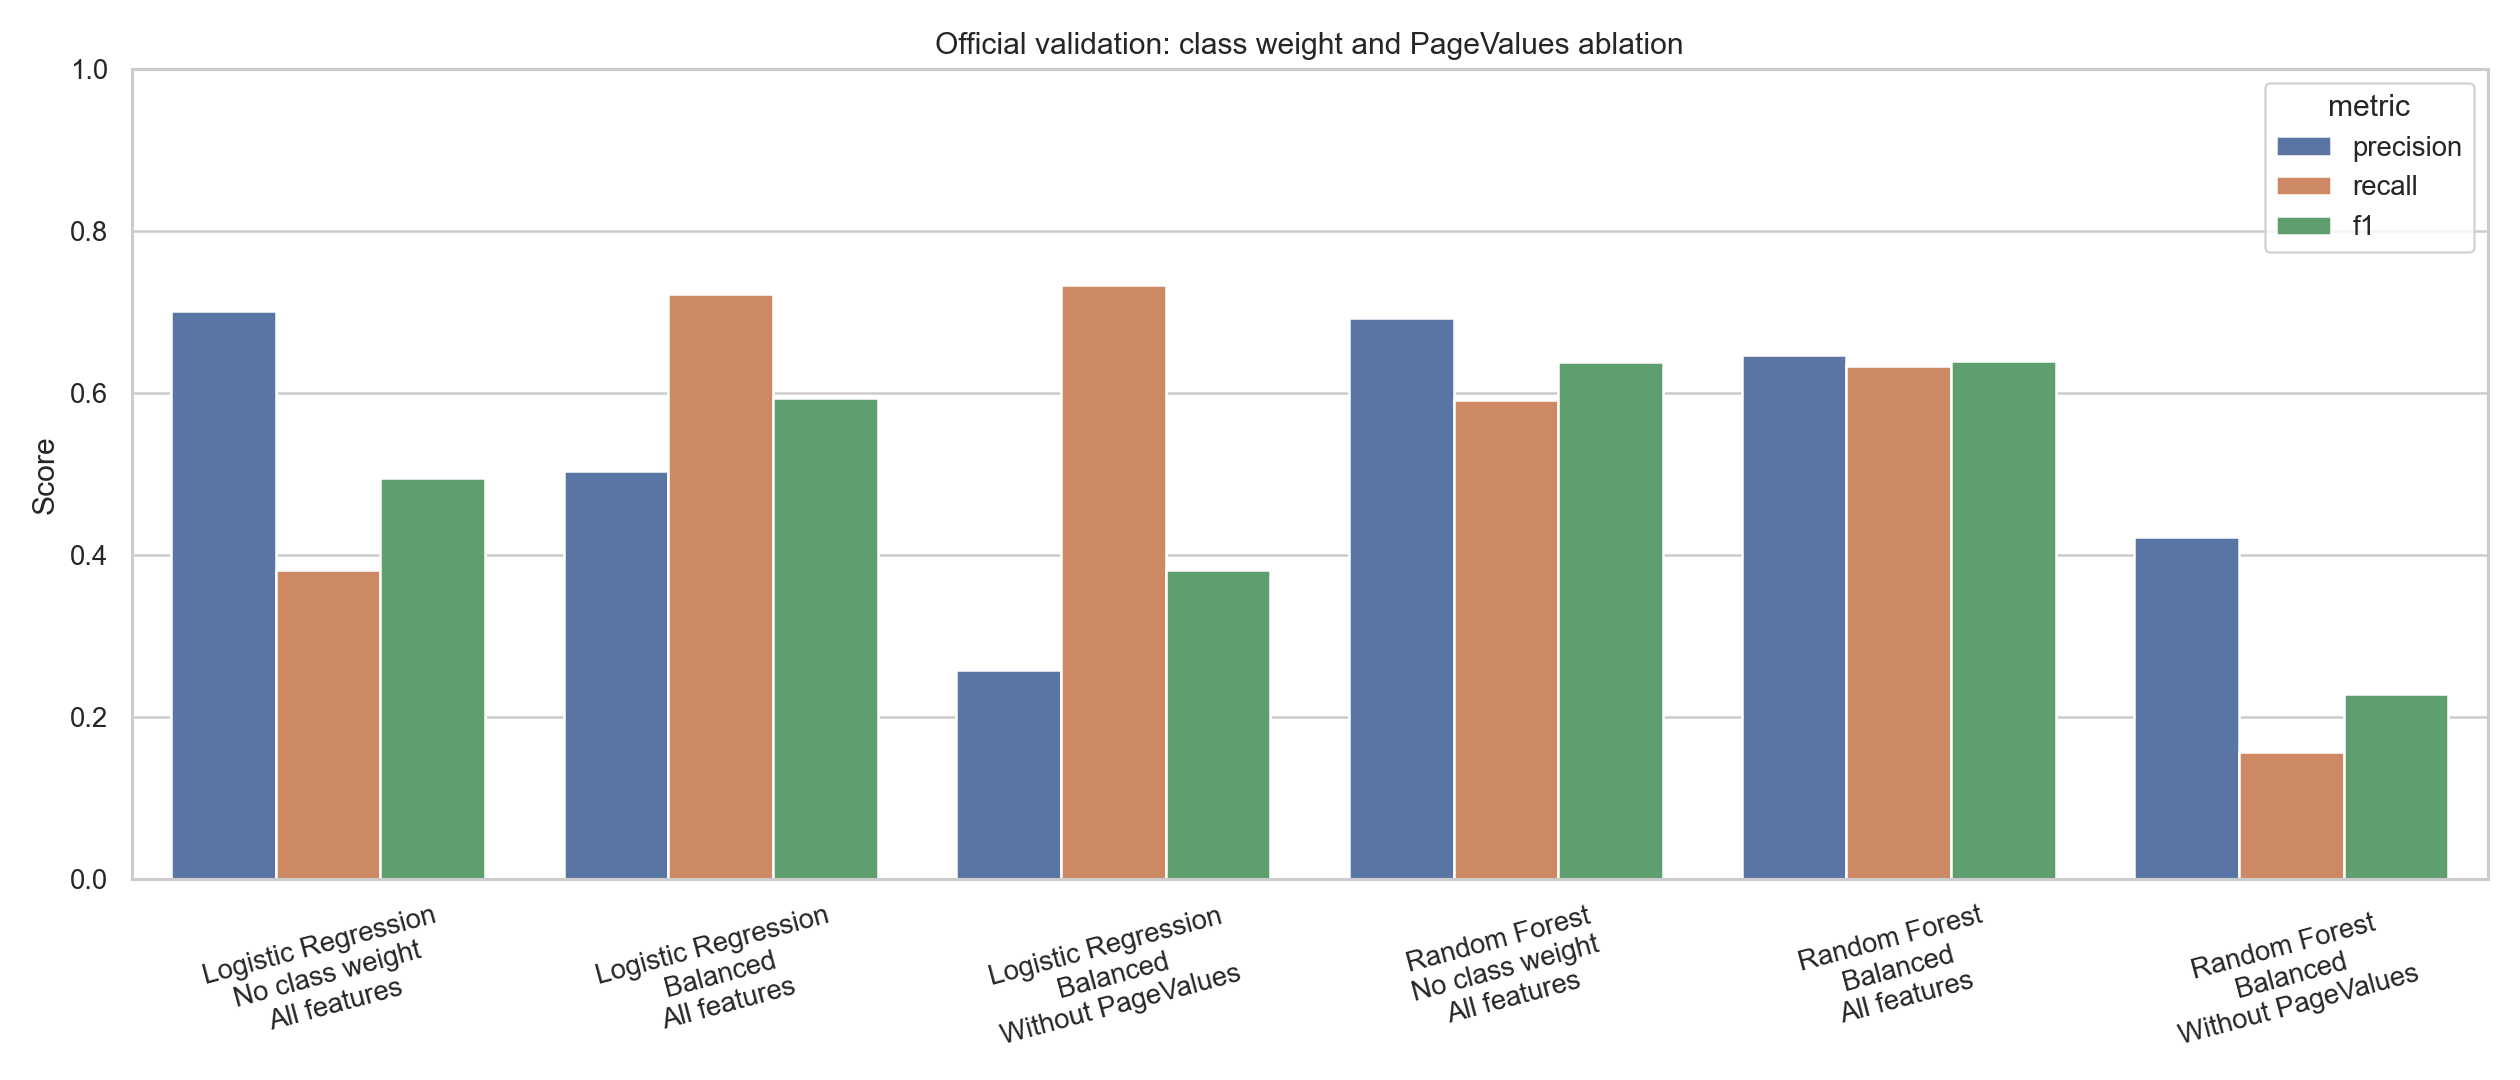

In [6]:
from run_ablation import main as run_ablation
run_ablation()
ablation = pd.read_csv(RESULT_ROOT / 'metrics' / 'validation_ablation_metrics.csv')
display(ablation.style.format(formatters))
display(Image(filename=str(RESULT_ROOT / 'figures' / 'validation_ablation_comparison.png')))

## 6. 해석 메모

- 정확도는 미구매 클래스가 많아 단독으로 사용하지 않는다.
- 기준선과 MLP 비교는 동일한 공식 validation 및 전처리에서 수행한다.
- 임계값 후보는 validation 결과이며 비즈니스 비용 합의 전에는 확정하지 않는다.
- `PageValues` 제외 결과로 예측 시점에서 이 특징을 사용할 수 있는지 점검한다.
- 팀의 모델과 임계값을 확정하기 전에는 `--evaluate-test`를 실행하지 않는다.